In [147]:
import torch
import numpy as np
from matplotlib import pyplot as plt
from typing import Tuple, Dict

In [ ]:
from dataclasses import dataclass, asdict, is_dataclass

@dataclass
class BrownianConfig:
    height: int = 240       # H
    width: int = 346         # W
    frames: int = 30000        # T
    num_points: int = 30    # N
    fps: int = 1000        
    size: int = 15

    # Diffusion coefficients 
    D_xy: float = 500.0  # pixel^2/s
    D_z: float = 500.0   # depth_units^2/s

    # Depth range 
    depth_min: float = 0.0
    depth_max: float = 255.0

    # Random seed 
    seed: int = 42

In [149]:
def simulate_brownian_dataset(cfg: BrownianConfig) -> Dict[str, np.ndarray]:
    rng = np.random.default_rng(cfg.seed)
    H, W, T, N = cfg.height, cfg.width, cfg.frames, cfg.num_points
    dt = 1.0 / cfg.fps

    # Precompute per-step standard deviations (Var = 2 * D * dt)
    sigma_xy = np.sqrt(2.0 * cfg.D_xy * dt)
    sigma_z  = np.sqrt(2.0 * cfg.D_z  * dt)

    # Initialize continuous positions uniformly within bounds
    # (y, x) = (row, col)
    y = rng.uniform(0, H - 1, size=N)
    x = rng.uniform(0, W - 1, size=N)
    z = rng.uniform(cfg.depth_min, cfg.depth_max, size=N)

    # Storage
    frames = np.zeros((T, H, W), dtype=np.uint8)
    tracks = np.zeros((T, N, 2), dtype=np.float32)       # (y, x) integer pixels
    depths = np.ones((T, N), dtype=np.uint8)        # depth values per point


    def reflect(pos, lower, upper):
        """
        Reflecting boundary conditions for 1D coordinate array.
        For any values outside [lower, upper], reflect them back into range.
        """
        span = upper - lower
        pos = pos - lower
        pos = np.mod(pos, 2 * span)
        mask = pos > span
        pos[mask] = 2 * span - pos[mask]
        return pos + lower

    for t in range(T):
        # Rasterize current positions (round to nearest pixel index)
        yi = np.clip(np.rint(y).astype(int), 0, H - cfg.size)
        xi = np.clip(np.rint(x).astype(int), 0, W - cfg.size)

        # frames[t, yi, xi] = 1
        
        ###############################################
        ### Increasing the pixel size of each point ###

        for dy in range(cfg.size):   # 0, 1, 2
            for dx in range(cfg.size):
                y2 = np.clip(yi + dy, 0, H - 1)
                x2 = np.clip(xi + dx, 0, W - 1)
                frames[t, y2, x2] = 1

        tracks[t, :, 0] = yi
        tracks[t, :, 1] = xi
        depths[t] = z.astype(np.float32)

        # Advance positions with Gaussian steps (independent per axis)
        y = y + rng.normal(0.0, sigma_xy, size=N)
        x = x + rng.normal(0.0, sigma_xy, size=N)
        z = z + rng.normal(0.0, sigma_z,  size=N)

        # Reflect at boundaries
        y = reflect(y, 0.0, H - cfg.size)
        x = reflect(x, 0.0, W - cfg.size)
        z = reflect(z, cfg.depth_min, cfg.depth_max)

    cfg_dict = asdict(cfg) if is_dataclass(cfg) else vars(cfg)
    meta = {
        "config": cfg_dict,
        "description": "Binary frames with N=100 Brownian points at 1000 fps; tracks are integer (y,x); depths are floats per point."
    }
    return {"frames": frames, "tracks": tracks, "depths": depths, "meta": meta}

In [150]:
cfg = BrownianConfig() 
data = simulate_brownian_dataset(cfg)

In [151]:
print(data.keys())
meta = data["meta"]
frames = data["frames"]
tracks = data["tracks"]
depths = data["depths"]

print(meta["config"])
print(frames.shape)
print(tracks.shape)
print(depths.shape)

dict_keys(['frames', 'tracks', 'depths', 'meta'])
{'height': 240, 'width': 346, 'frames': 30000, 'num_points': 30, 'fps': 1000, 'size': 15, 'D_xy': 500.0, 'D_z': 500.0, 'depth_min': 0.0, 'depth_max': 255.0, 'seed': 21}
(30000, 240, 346)
(30000, 30, 2)
(30000, 30)


In [152]:
tensor_frames = torch.from_numpy(frames) * 255
tensor_depths = torch.from_numpy(depths)
tensor_tracks = torch.from_numpy(tracks)

In [153]:

# assumes you already have:
# tensor_frames : (T, H, W)  (only used for shape)
# tensor_tracks : (T, N, 2)  long/int  [y, x]  (top-left pixel of the 15×15 block)
# tensor_depths : (T, N)     float

#Depth c

T, H, W = tensor_frames.shape
device  = tensor_depths.device

# initialize like your code (background depth = 1.0)
tensor_depthmaps = torch.ones((T, H, W), dtype=tensor_depths.dtype, device=device)
tensor_depthmaps = tensor_depthmaps * 255  
size = 15
# precompute 15x15 offsets (top-left convention; for centered subtract size//2 below)
oy = torch.arange(size, device=device)
ox = torch.arange(size, device=device)
OY, OX = torch.meshgrid(oy, ox, indexing='ij')   # (size, size)
OY = OY.reshape(-1, 1)                           # (K, 1)
OX = OX.reshape(-1, 1)                           # (K, 1)
K = size * size

for t in range(T):
    # (N,)
    y = tensor_tracks[t, :, 0].to(device).long()
    x = tensor_tracks[t, :, 1].to(device).long()
    d = tensor_depths[t].to(device)              # (N,)

    # (K, N) coordinates for each point's 15×15 block
    Y = (y.unsqueeze(0) + OY).clamp_(0, H - size)
    X = (x.unsqueeze(0) + OX).clamp_(0, W - size)

    # flatten to 1D linear indices and broadcast depths
    lin  = (Y * W + X).reshape(-1)               # (K*N,)
    vals = d.expand(K, y.numel()).reshape(-1)    # (K*N,)

    # write into the frame (last write wins for overlaps)
    tensor_depthmaps[t].view(-1).index_copy_(0, lin, vals)


In [154]:
def compute_event_frame(diff):
    """
    Implements equation (3) from "Differentiable Event Stream Simulator for Non-Rigid 3D Tracking.
    The parameter values for eps and w are chosen by my best guess. C is chosen to be what was used
    in the Vid2Events codebase for their event simulation method.
    """

    eps = 1e-6
    C = 0.05
    w = 100
    return ((diff + eps) / (torch.abs(diff) + eps)) * (1 / (1 + torch.exp(-w*torch.abs(diff)+w*C)))

tensor_frames.shape : torch.Size([10, 240, 346])
diffs.shape : torch.Size([9, 240, 346])


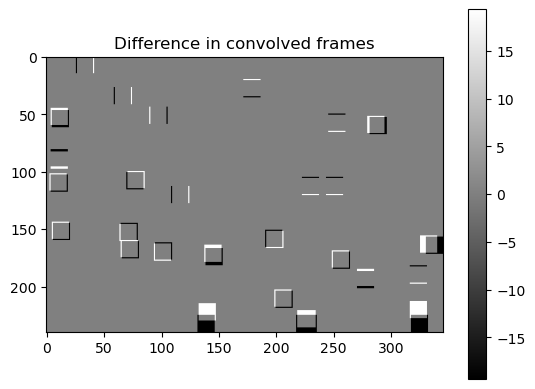

In [155]:
epsilon = 1e-6
test = tensor_frames[0:10, :, :]
log_frames = torch.log(test + epsilon)
print(f"tensor_frames.shape : {test.shape}")
diffs = log_frames[1:] - log_frames[:-1] 
print(f"diffs.shape : {diffs.shape}")

plt.imshow(diffs[0].detach().numpy(), cmap = 'gray')
plt.title('Difference in convolved frames')
plt.colorbar()

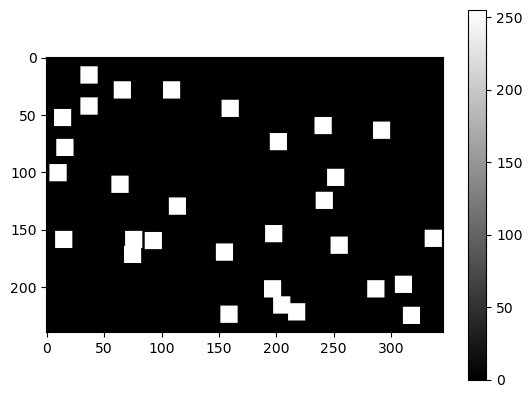

torch.uint8


In [156]:
plt.imshow(tensor_frames[100].cpu().numpy(), cmap='gray')
plt.colorbar()
plt.show()
print(tensor_frames.dtype)

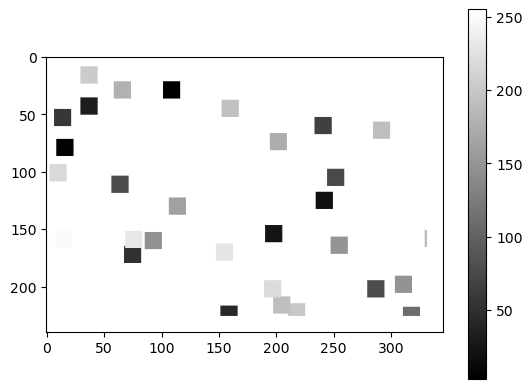

torch.uint8


In [157]:
plt.imshow(tensor_depthmaps[100].cpu().numpy(), cmap='gray')
plt.colorbar()
plt.show()
print(tensor_depthmaps.dtype)

In [158]:
print(tensor_depthmaps.shape)
print(tensor_frames.shape)

torch.Size([30000, 240, 346])
torch.Size([30000, 240, 346])


In [159]:
# from PIL import Image
# import os
# save_dir = "/home/yl3836/DENSE/train_sparse_v2/train_seed_21/frames/"
# save_dir = "/home/yl3836/DENSE/valid_sparse_v2/valid_seed_50/"
# os.makedirs(save_dir, exist_ok=True)

# # 텐서를 numpy로 변환
# img = tensor_frames[100].cpu().numpy()

# # dtype이 uint8이면 바로 Image로 변환 가능
# img_pil = Image.fromarray(img)

# # 저장
# save_path = os.path.join(save_dir, "framemap_100.png")
# img_pil.save(save_path)

# print(f"Saved image to: {save_path}")


## Generating Dataset

In [ ]:
import torch
import os
import imageio as imageio
from tqdm import tqdm

save_dir = "/home/yl3836/DENSE/train_sparse_v2/train_seed_42/imgs/"
#save_dir = "/home/yl3836/DENSE/valid_sparse_v2/valid_seed_50/imgs/"
os.makedirs(save_dir, exist_ok=True)

# tensor_depths가 (N, H, W) 또는 (N, 1, H, W) 형태일 경우 처리
#tensor_depths = tensor_depths.squeeze()

print(f"Saving {tensor_depthmaps.shape[0]} depth images to {save_dir} ...")

for i in tqdm(range(tensor_depthmaps.shape[0]), desc="Saving depth images"):
    img = tensor_depthmaps[i].cpu().numpy()
    img_pil = Image.fromarray(img)

    save_path = os.path.join(save_dir, f"{i:08d}.png")
    img_pil.save(save_path)

print(f"✅ Done! Saved {tensor_depthmaps.shape[0]} images to {save_dir}")


Saving 30000 depth images to /home/yl3836/DENSE/train_sparse_v2/train_seed_21/imgs/ ...


Saving depth images: 100%|██████████| 30000/30000 [01:32<00:00, 324.93it/s]

✅ Done! Saved 30000 images to /home/yl3836/DENSE/train_sparse_v2/train_seed_21/imgs/


In [ ]:
import torch
import os
import imageio as imageio
from tqdm import tqdm

save_dir = "/home/yl3836/DENSE/train_sparse_v2/train_seed_42/frames/"
#save_dir = "/home/yl3836/DENSE/valid_sparse_v2/valid_seed_50/frames/"
os.makedirs(save_dir, exist_ok=True)

# tensor_depths가 (N, H, W) 또는 (N, 1, H, W) 형태일 경우 처리
#tensor_depths = tensor_depths.squeeze()

print(f"Saving {tensor_frames.shape[0]} frame images to {save_dir} ...")


for i in tqdm(range(tensor_frames.shape[0]), desc="Saving frame images"):
    img = tensor_frames[i].cpu().numpy()
    img_pil = Image.fromarray(img)

    save_path = os.path.join(save_dir, f"{i:08d}.png")
    img_pil.save(save_path)

print(f"✅ Done! Saved {tensor_frames.shape[0]} images to {save_dir}")


Saving 30000 frame images to /home/yl3836/DENSE/train_sparse_v2/train_seed_21/frames/ ...


Saving frame images: 100%|██████████| 30000/30000 [01:33<00:00, 321.53it/s]

✅ Done! Saved 30000 images to /home/yl3836/DENSE/train_sparse_v2/train_seed_21/frames/


In [17]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# 이미지 경로
img_path = "//home/yl3836/DENSE/train_sparse/train_seed_21_new/frames/00000000.png"

# 이미지 읽기
img = mpimg.imread(img_path)

# 이미지 plot
plt.imshow(img)
plt.axis('off')  # 축 제거
plt.title("Frame 00028042")
plt.colorbar()
plt.show()



FileNotFoundError: [Errno 2] No such file or directory: '//home/yl3836/DENSE/train_sparse/train_seed_21_new/frames/00000000.png'

# PLOTTING

In [84]:
import matplotlib.pyplot as plt
import numpy as np

def plot_brownian_summary(data, cfg, frame_idx=0, point_idx=0):

    t = np.arange(cfg.frames) / cfg.fps

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # fig #1 = frame image
    ax = axes[0]
    ax.imshow(data["frames"][frame_idx], origin="upper", cmap="gray")
    ax.set_title(f"Frame {frame_idx} (binary mask)")
    ax.axis("off")

    # fig #2 = trajectory of specific point
    ax = axes[1]
    ax.plot(t, data["tracks"][:, point_idx, 1], label="x (px)")
    ax.plot(t, data["tracks"][:, point_idx, 0], label="y (px)")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Pixel coordinate")
    ax.set_title(f"Trajectory of point {point_idx}")
    ax.legend()
    ax.grid(alpha=0.3)

    # fig #3 = depth trace of specific point
    ax = axes[2]
    ax.plot(t, data["depths"][:, point_idx], color="tab:orange")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Depth (units)")
    ax.set_title(f"Depth trace of point {point_idx}")
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


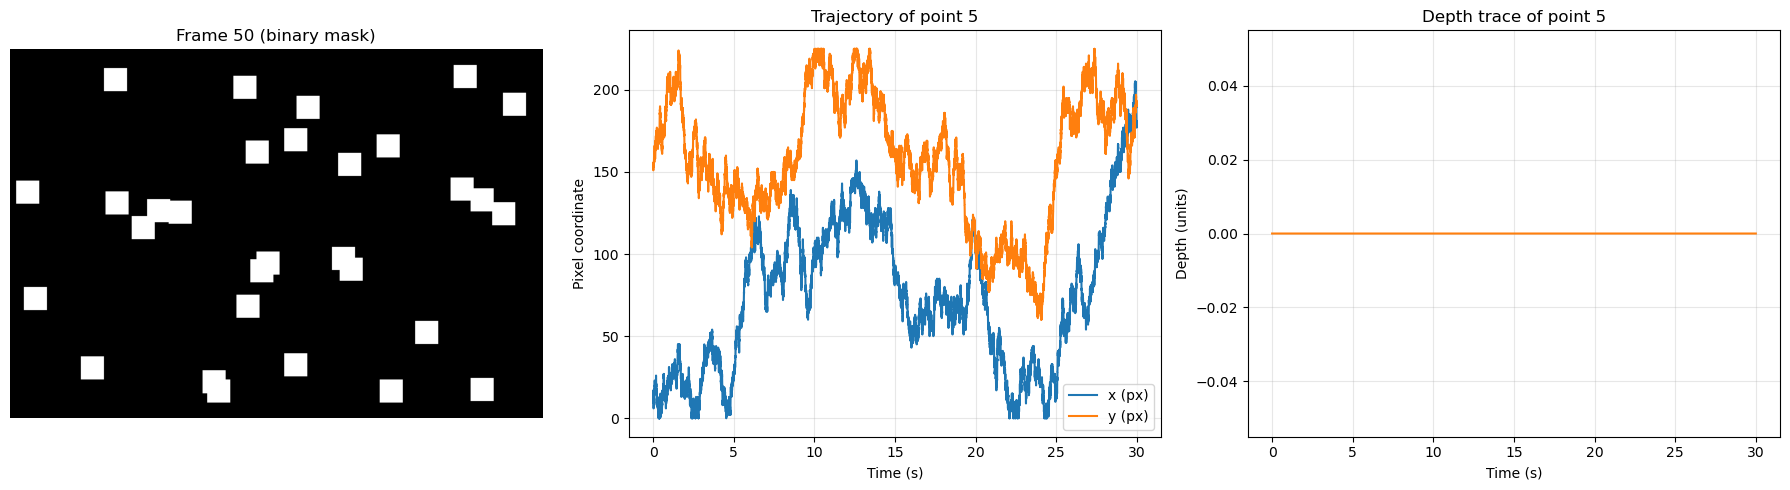

In [85]:
plot_brownian_summary(data, cfg, frame_idx=50, point_idx=5)

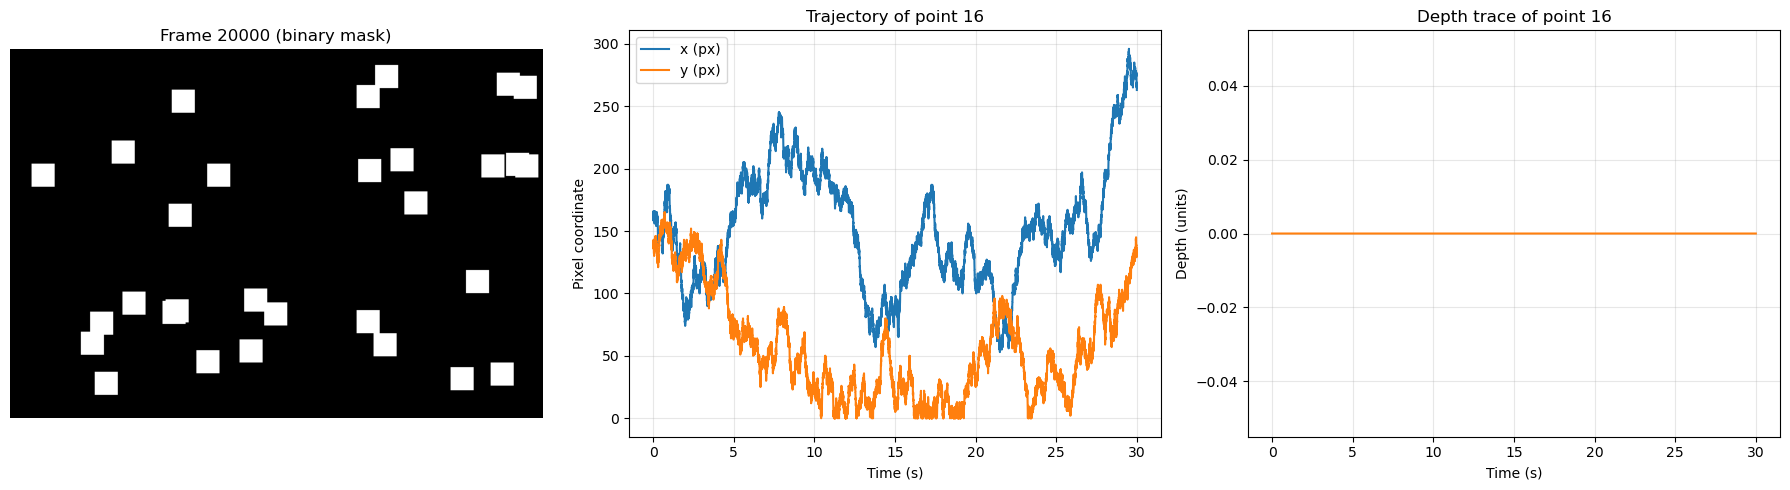

In [86]:
plot_brownian_summary(data, cfg, frame_idx=20000, point_idx=16)

In [35]:
def plot_point_cloud_3d_at_frame(data, frame_idx):
    """
    특정 프레임에서 모든 점의 (x,y,z)를 3D 산점도로 표시.
    """
    yi = data["tracks"][frame_idx, :, 0]
    xi = data["tracks"][frame_idx, :, 1]
    zi = data["depths"][frame_idx, :]

    fig = plt.figure(figsize=(4, 3))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(xi, yi, zi, s=12)  # 작은 점 구름

    ax.set_xlabel("x (px)")
    ax.set_ylabel("y (px)")
    ax.set_zlabel("depth (units)")
    ax.set_title(f"3D point cloud at frame {frame_idx}")
    ax.set_ylim(0, 200)
    plt.show()

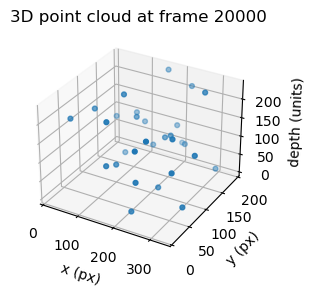

In [36]:
plot_point_cloud_3d_at_frame(data, frame_idx=20000)

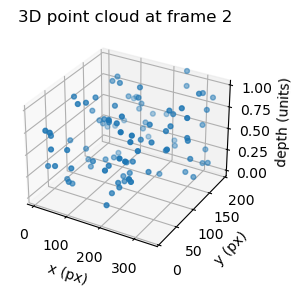

In [ ]:
plot_point_cloud_3d_at_frame(data, frame_idx=2)

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # 3D 플롯 지원
import numpy as np
import imageio
import os

def save_brownian_3d_gif(data, out_path="brownian_3d.gif", size=(4, 3), point_size=6, fps=20, step=5):
    """
    모든 프레임을 3D 산점도로 그리고 GIF 애니메이션으로 저장.
    
    Parameters
    ----------
    data : dict
        simulate_brownian_dataset(cfg) 결과 (frames, tracks, depths)
    out_path : str
        저장할 GIF 파일 경로
    size : tuple
        figure 크기 (inch 단위)
    point_size : int
        점 크기
    fps : int
        GIF 재생 프레임레이트 (frames per second)
    step : int
        프레임 간격 (예: 5면 5프레임마다 1장 저장)
    """
    os.makedirs("frames_tmp", exist_ok=True)
    H, W = data["frames"].shape[1:3]
    T = data["frames"].shape[0]

    filenames = []
    for t in range(0, T, step):
        yi = data["tracks"][t, :, 0]
        xi = data["tracks"][t, :, 1]
        zi = data["depths"][t, :]

        fig = plt.figure(figsize=size)
        ax = fig.add_subplot(111, projection='3d')
        ax.scatter(xi, yi, zi, s=point_size)
        ax.set_xlim(0, W)
        ax.set_ylim(0, H)
        ax.set_zlim(data["depths"].min(), data["depths"].max())
        ax.set_title(f"Frame {t}")
        ax.set_xlabel("x (px)")
        ax.set_ylabel("y (px)")
        ax.set_zlabel("depth (units)")

        # 이미지 저장
        filename = f"frames_tmp/frame_{t:05d}.png"
        plt.tight_layout()
        plt.savefig(filename)
        plt.close(fig)
        filenames.append(filename)

    # GIF로 묶기
    images = [imageio.imread(fn) for fn in filenames]
    imageio.mimsave(out_path, images, fps=fps)
    print(f"✅ Saved: {out_path}")

    # # 임시 파일 삭제 (원하면 유지 가능)
    # for fn in filenames:
    #     os.remove(fn)
    # os.rmdir("frames_tmp")


In [ ]:
save_brownian_3d_gif(data, out_path="brownian_motion_30 step.gif", size=(4,3), point_size=4, fps=30, step=30)


✅ Saved: brownian_motion_30 step.gif
